# E-Commerce Customer Intelligence

## Objective
Analyze e-commerce customer and transaction data to understand
customer behavior, product performance, purchasing patterns,
and business opportunities.

## Tools
Python | Pandas | NumPy | Plotly | SQL

In [ ]:
!pip install -q openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from io import BytesIO
import requests

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url, engine="openpyxl")

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)

✅ Dataset loaded successfully!
Shape: (541909, 8)


In [48]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Day,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,Dec,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Dec,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,Dec,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Dec,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Dec,1,8,Wednesday


In [ ]:
print("===== DATASET INFORMATION =====")
df.info()

print("\n===== MISSING VALUES =====")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n===== DUPLICATE RECORDS =====")
print("Duplicate rows:", df.duplicated().sum())

print("\n===== DATASET SUMMARY =====")
print(df.describe(include="all").T)

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

===== MISSING VALUES =====
Description      1454
CustomerID     135080
dtype: int64

===== DUPLICATE RECORDS =====
Duplicate rows: 5268

===== DATASET SUMMARY =====
                count   unique                                 top    freq  \
InvoiceNo    541909.0  25900.0  

In [49]:
df = df.drop_duplicates()

df = df.dropna(subset=["CustomerID"])

df["CustomerID"] = df["CustomerID"].astype(int)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.strftime("%b")
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

print("Data cleaning completed!")
print("Cleaned dataset shape:", df.shape)

display(df.head())

Data cleaning completed!
Cleaned dataset shape: (392692, 15)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Day,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,Dec,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Dec,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,Dec,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Dec,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Dec,1,8,Wednesday


In [50]:
total_sales = df["TotalSales"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
average_order_value = total_sales / total_orders

print("===== KEY BUSINESS METRICS =====")
print(f"Total Sales: £{total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

print("\n===== TOP 10 PRODUCTS =====")
top_products = (
    df.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_products)

print("\n===== TOP 10 CUSTOMERS =====")
top_customers = (
    df.groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_customers)

===== KEY BUSINESS METRICS =====
Total Sales: £8,887,208.89
Total Orders: 18,532
Total Customers: 4,338
Total Products: 3,665
Average Order Value: £479.56

===== TOP 10 PRODUCTS =====


,Description,TotalSales
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,JUMBO BAG RED RETROSPOT,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68785.23
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,Manual,53419.93
9,RABBIT NIGHT LIGHT,51251.24



===== TOP 10 CUSTOMERS =====


,CustomerID,TotalSales
0,14646,280206.02
1,18102,259657.30
2,17450,194390.79
3,16446,168472.50
4,14911,143711.17
5,12415,124914.53
6,14156,117210.08
7,17511,91062.38
8,16029,80850.84
9,12346,77183.60


In [61]:
monthly_sales = (
    df.groupby(["Year", "Month", "MonthName"])["TotalSales"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)

monthly_sales["Period"] = (
    monthly_sales["MonthName"] + " " + monthly_sales["Year"].astype(str)
)

display(monthly_sales[["Period", "TotalSales"]])

,Period,TotalSales
0,Dec 2010,570422.730
1,Jan 2011,568101.310
2,Feb 2011,446084.920
3,Mar 2011,594081.760
4,Apr 2011,468374.331
5,May 2011,677355.150
6,Jun 2011,660046.050
7,Jul 2011,598962.901
8,Aug 2011,644051.040
9,Sep 2011,950690.202


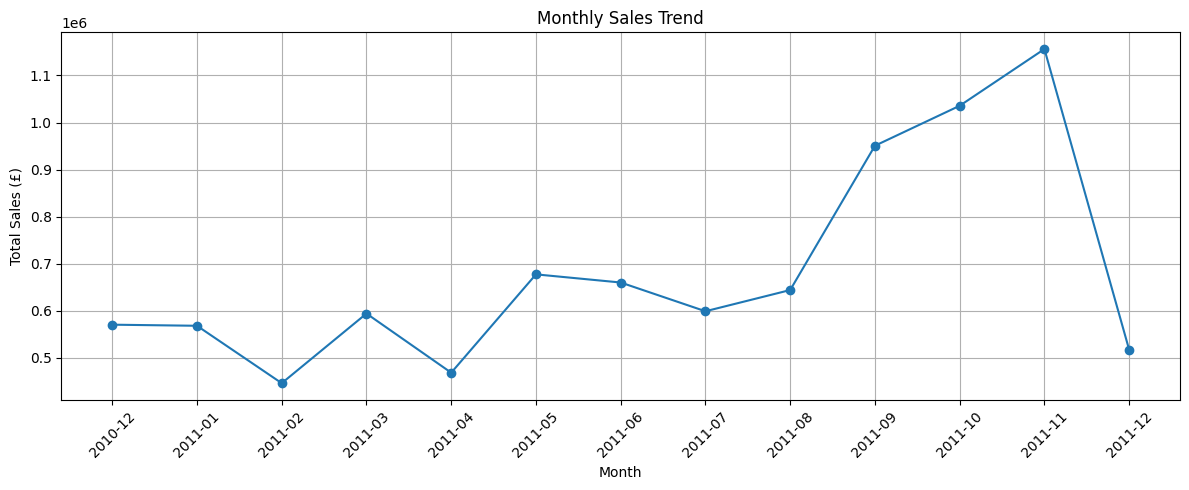

In [60]:
monthly_sales = df.groupby(["Year", "Month"])["TotalSales"].sum().reset_index()
monthly_sales["Period"] = monthly_sales["Year"].astype(str) + "-" + monthly_sales["Month"].astype(str).str.zfill(2)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Period"], monthly_sales["TotalSales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

,Description,TotalSales
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,JUMBO BAG RED RETROSPOT,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68785.23
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,Manual,53419.93
9,RABBIT NIGHT LIGHT,51251.24


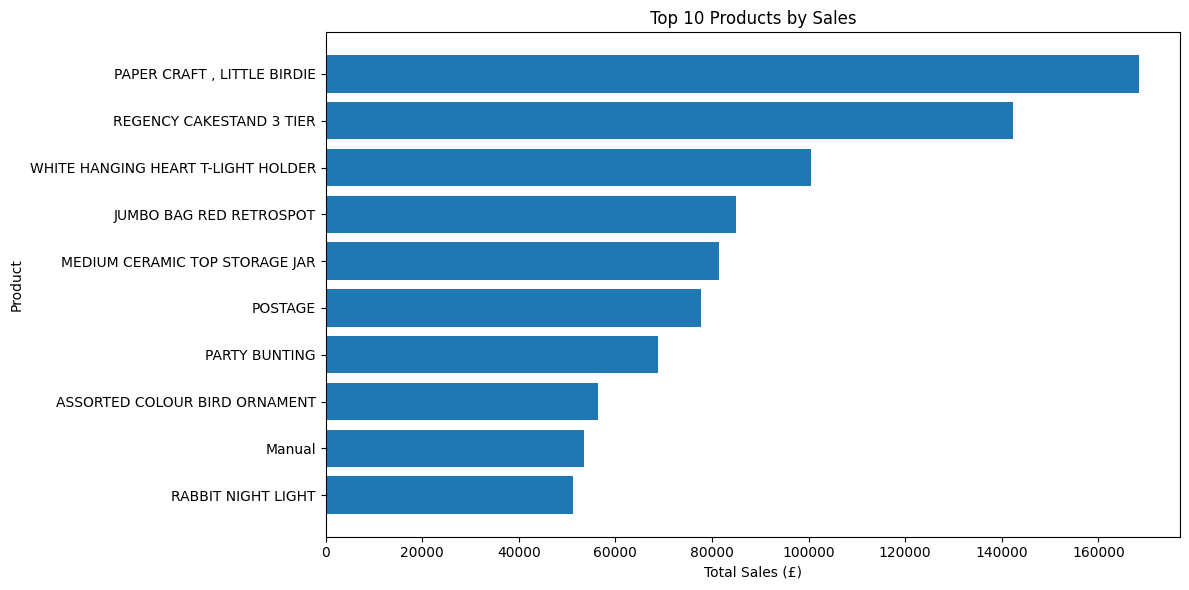

In [59]:
top_products = (
    df.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_products)

plt.figure(figsize=(12,6))
plt.barh(top_products["Description"][::-1], top_products["TotalSales"][::-1])
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

,CustomerID,TotalSales
0,14646,280206.02
1,18102,259657.30
2,17450,194390.79
3,16446,168472.50
4,14911,143711.17
5,12415,124914.53
6,14156,117210.08
7,17511,91062.38
8,16029,80850.84
9,12346,77183.60


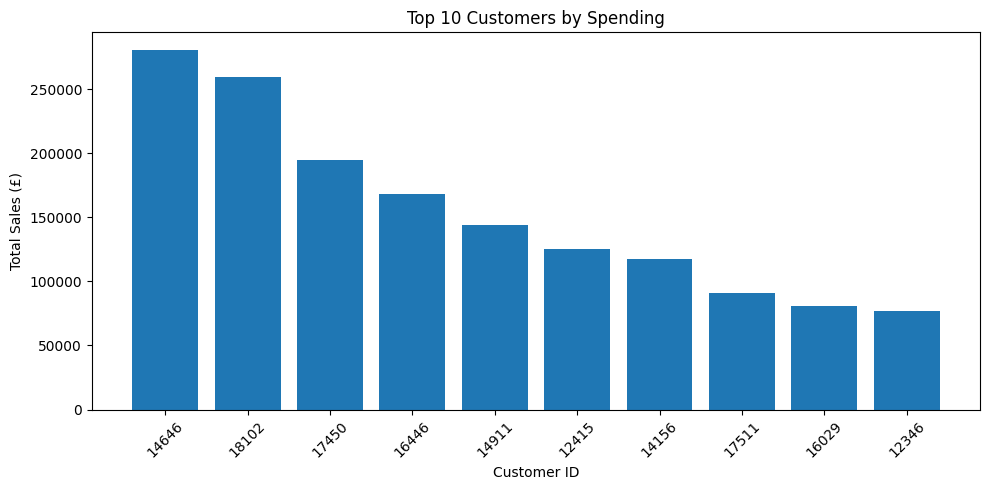

In [58]:
top_customers = (
    df.groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_customers)

plt.figure(figsize=(10,5))
plt.bar(
    top_customers["CustomerID"].astype(str),
    top_customers["TotalSales"]
)
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,CustomerID,NumberOfOrders
0,12748,209
1,14911,201
2,17841,124
3,13089,97
4,14606,93
5,15311,91
6,12971,86
7,14646,73
8,16029,63
9,13408,62


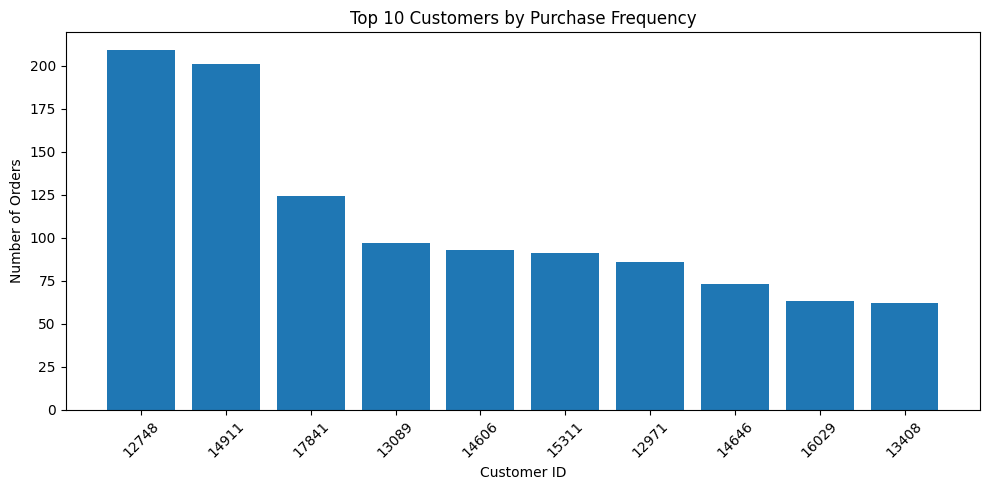

In [57]:
purchase_frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

purchase_frequency.columns = ["CustomerID", "NumberOfOrders"]

display(purchase_frequency)

plt.figure(figsize=(10,5))
plt.bar(
    purchase_frequency["CustomerID"].astype(str),
    purchase_frequency["NumberOfOrders"]
)
plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Country,TotalSales
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


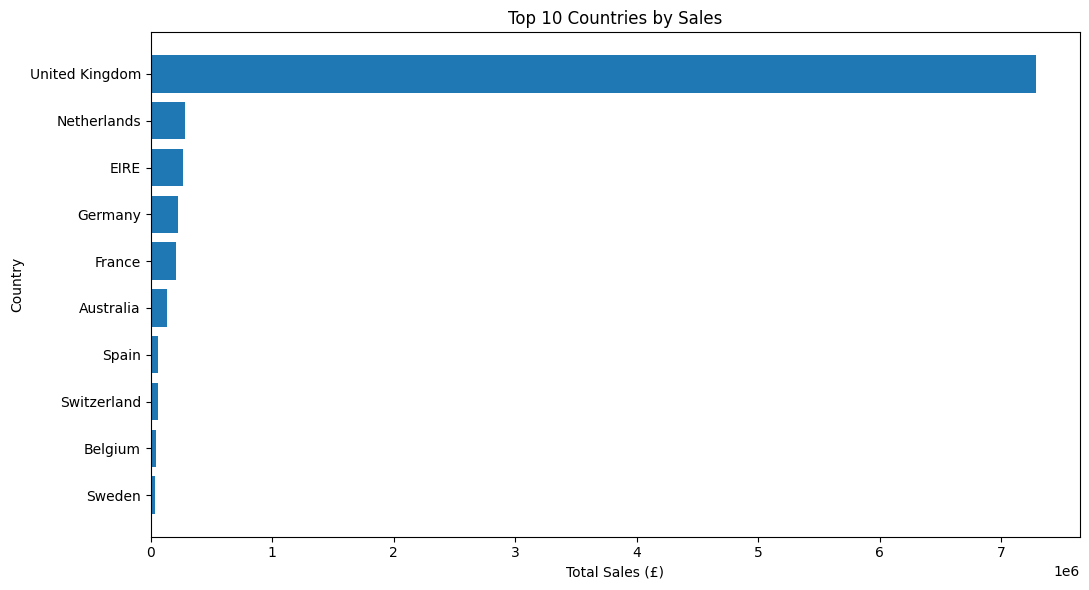

In [56]:
country_sales = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(country_sales)

plt.figure(figsize=(11,6))
plt.barh(
    country_sales["Country"][::-1],
    country_sales["TotalSales"][::-1]
)
plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

,DayOfWeek,TotalSales
0,Monday,1363604.401
1,Tuesday,1697733.801
2,Wednesday,1584283.830
3,Thursday,1973015.730
4,Friday,1483080.811
5,Saturday,NaN
6,Sunday,785490.321


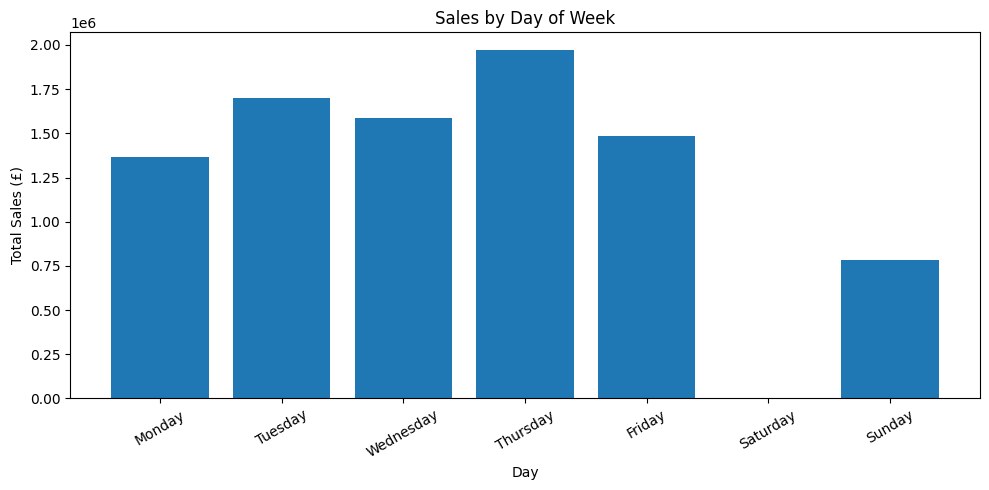

In [55]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_sales = (
    df.groupby("DayOfWeek")["TotalSales"]
    .sum()
    .reindex(day_order)
    .reset_index()
)

display(day_sales)

plt.figure(figsize=(10,5))
plt.bar(day_sales["DayOfWeek"], day_sales["TotalSales"])
plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

,Hour,TotalSales
0,6,4.250
1,7,31059.210
2,8,281997.790
3,9,842392.341
4,10,1259267.591
5,11,1101177.600
6,12,1373695.390
7,13,1168724.200
8,14,991992.821
9,15,963559.680


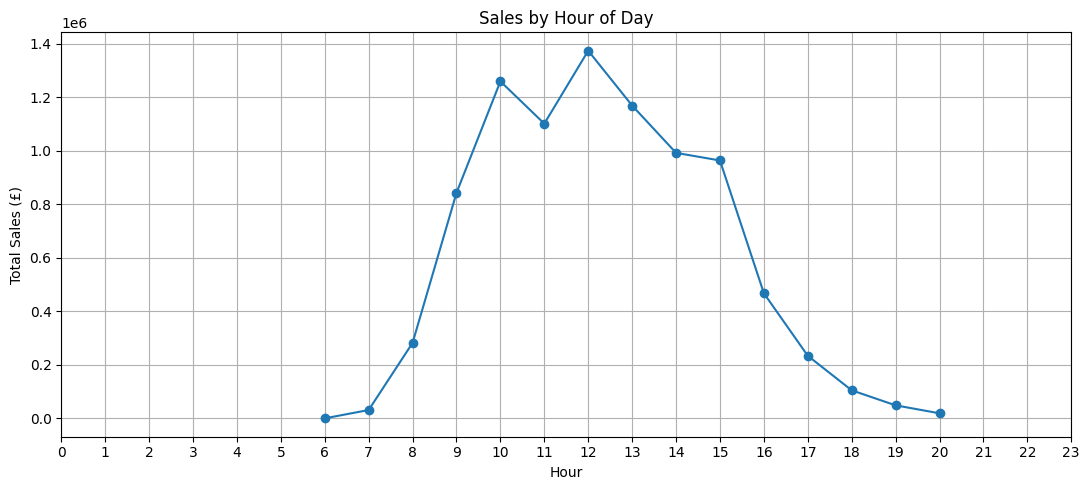

In [54]:
hourly_sales = (
    df.groupby("Hour")["TotalSales"]
    .sum()
    .reset_index()
)

display(hourly_sales)

plt.figure(figsize=(11,5))
plt.plot(
    hourly_sales["Hour"],
    hourly_sales["TotalSales"],
    marker="o"
)
plt.title("Sales by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total Sales (£)")
plt.xticks(range(0,24))
plt.grid(True)
plt.tight_layout()
plt.show()

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
3,JUMBO BAG RED RETROSPOT,46078
4,WHITE HANGING HEART T-LIGHT HOLDER,36706
5,ASSORTED COLOUR BIRD ORNAMENT,35263
6,PACK OF 72 RETROSPOT CAKE CASES,33670
7,POPCORN HOLDER,30919
8,RABBIT NIGHT LIGHT,27153
9,MINI PAINT SET VINTAGE,26076


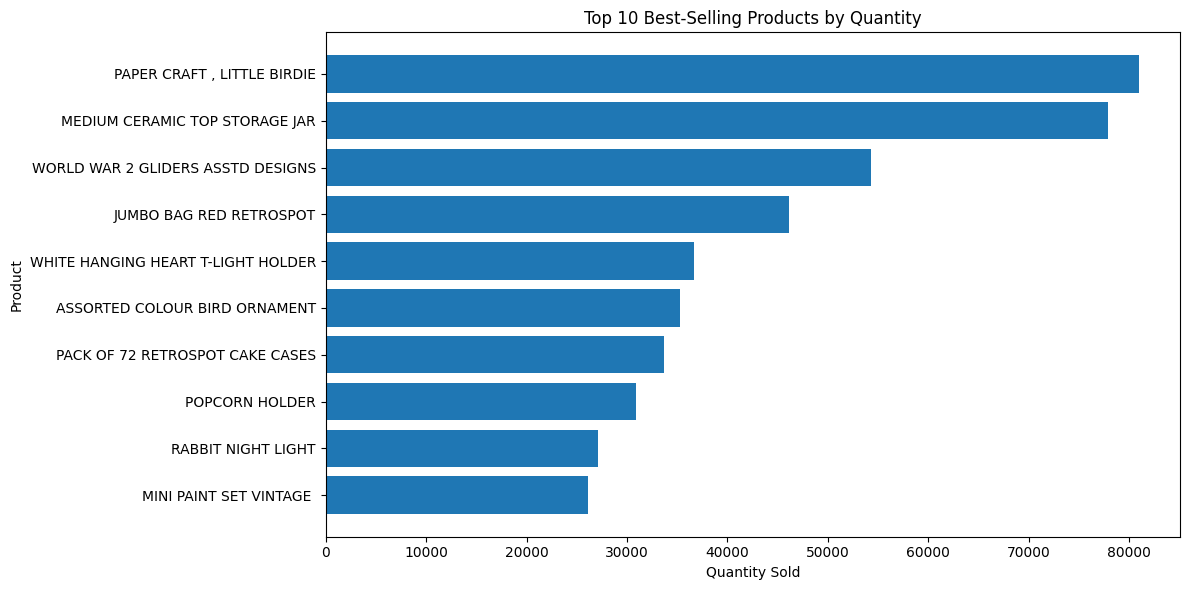

In [53]:
top_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_quantity)

plt.figure(figsize=(12,6))
plt.barh(
    top_quantity["Description"][::-1],
    top_quantity["Quantity"][::-1]
)
plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [52]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalSales", "sum")
).reset_index()

rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

def segment(row):
    if row["R_Score"] >= 3 and row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "Champions"
    elif row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "Loyal Customers"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 2:
        return "At Risk"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Lost Customers"
    else:
        return "Potential Customers"

rfm["Segment"] = rfm.apply(segment, axis=1)

display(rfm.head(10))

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Total_Sales=("Monetary", "sum"),
        Average_Spend=("Monetary", "mean")
    )
    .sort_values("Customers", ascending=False)
    .reset_index()
)

display(segment_summary)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,4,114,Lost Customers
1,12347,2,7,4310.00,4,4,4,444,Champions
2,12348,75,4,1797.24,2,3,4,234,Loyal Customers
3,12349,19,1,1757.55,3,1,4,314,Potential Customers
4,12350,310,1,334.40,1,1,2,112,Lost Customers
5,12352,36,8,2506.04,3,4,4,344,Champions
6,12353,204,1,89.00,1,1,1,111,Lost Customers
7,12354,232,1,1079.40,1,1,3,113,Lost Customers
8,12355,214,1,459.40,1,1,2,112,Lost Customers
9,12356,23,3,2811.43,3,3,4,334,Champions


,Segment,Customers,Total_Sales,Average_Spend
0,Champions,1312,6476424.831,4936.299414
1,At Risk,883,456563.532,517.059493
2,Potential Customers,857,587394.800,685.408168
3,Lost Customers,832,398774.671,479.296480
4,Loyal Customers,454,968051.060,2132.271057


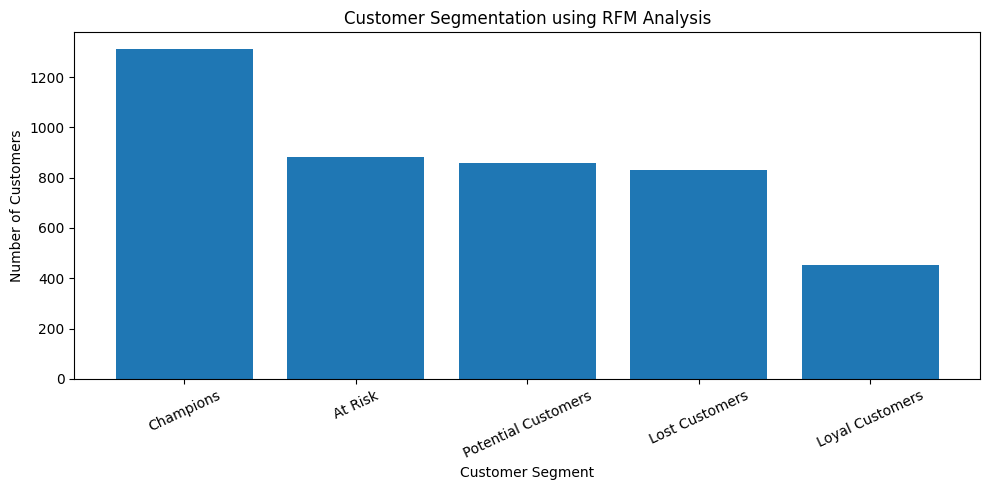

In [51]:
plt.figure(figsize=(10,5))
plt.bar(
    segment_summary["Segment"],
    segment_summary["Customers"]
)
plt.title("Customer Segmentation using RFM Analysis")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [38]:
best_month = monthly_sales.loc[
    monthly_sales["TotalSales"].idxmax(), "Period"
]

best_month_sales = monthly_sales["TotalSales"].max()

best_product = top_products.iloc[0]["Description"]
best_product_sales = top_products.iloc[0]["TotalSales"]

best_country = country_sales.iloc[0]["Country"]
best_country_sales = country_sales.iloc[0]["TotalSales"]

best_day = day_sales.loc[
    day_sales["TotalSales"].idxmax(), "DayOfWeek"
]

best_hour = hourly_sales.loc[
    hourly_sales["TotalSales"].idxmax(), "Hour"
]

largest_segment = segment_summary.iloc[0]["Segment"]
largest_segment_count = segment_summary.iloc[0]["Customers"]

print("===== BUSINESS INSIGHTS =====\n")

print(f"1. Highest sales period: {best_month} with £{best_month_sales:,.2f} in sales.")
print(f"2. Best-performing product: {best_product} with £{best_product_sales:,.2f} in sales.")
print(f"3. Top sales country: {best_country} with £{best_country_sales:,.2f} in sales.")
print(f"4. Highest-sales day of the week: {best_day}.")
print(f"5. Highest-sales hour: {best_hour}:00.")
print(f"6. Largest customer segment: {largest_segment} with {largest_segment_count:,} customers.")

print("\n===== BUSINESS RECOMMENDATIONS =====\n")

print("1. Focus inventory and promotions on the highest-performing products.")
print("2. Plan campaigns around the strongest sales periods.")
print("3. Prioritize high-value countries for marketing and expansion.")
print("4. Use customer segmentation to create targeted retention campaigns.")
print("5. Re-engage At Risk and Lost Customers with personalized offers.")
print("6. Reward Champions and Loyal Customers to encourage repeat purchases.")

===== BUSINESS INSIGHTS =====

1. Highest sales period: 2011-11 with £1,156,205.61 in sales.
2. Best-performing product: PAPER CRAFT , LITTLE BIRDIE with £168,469.60 in sales.
3. Top sales country: United Kingdom with £7,285,024.64 in sales.
4. Highest-sales day of the week: Thursday.
5. Highest-sales hour: 12:00.
6. Largest customer segment: Champions with 1,312 customers.

===== BUSINESS RECOMMENDATIONS =====

1. Focus inventory and promotions on the highest-performing products.
2. Plan campaigns around the strongest sales periods.
3. Prioritize high-value countries for marketing and expansion.
4. Use customer segmentation to create targeted retention campaigns.
5. Re-engage At Risk and Lost Customers with personalized offers.
6. Reward Champions and Loyal Customers to encourage repeat purchases.
